<a href="https://colab.research.google.com/github/Lattemelia/Portfolio/blob/main/%E3%80%900624%EF%BD%9E%E7%8F%BE%E5%9C%A8%E4%BD%9C%E6%88%90%E4%B8%AD%E3%80%91/%E4%B8%AD%E5%8F%A4%E8%BB%8A%E3%81%AE%E4%BE%A1%E6%A0%BC%E4%BA%88%E6%B8%AC(KaggleConpe).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 新しいセクション

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
PATH = r"/content/drive/MyDrive/Colab Notebooks"

test_df = pd.read_csv(PATH + r"/test.csv")
train_df = pd.read_csv(PATH + r"/train.csv")

marged_df = pd.concat([test_df,train_df],axis=0)

In [ ]:
cols_to_lower = ['brand', 'model', 'engine', 'fuel_type', 'transmission']

for col in cols_to_lower:
    marged_df[col] = marged_df[col].str.lower().str.strip()

In [ ]:
brands_to_exclude = ['smart', 'polestar']
rows_to_drop = marged_df[marged_df['brand'].isin(brands_to_exclude)].index
marged_df = marged_df.drop(rows_to_drop)

In [ ]:
fuel_pattern = r'(gasoline|diesel|e85 flex fuel|flex fuel|electric|hybrid|plug-in hybrid)'

for df in [marged_df]:
    df['fuel_type'] = df['fuel_type'].replace(['–', 'not supported'], np.nan)
    extracted = df['engine'].str.extract(fuel_pattern, expand=False, flags=re.IGNORECASE)
    df['fuel_type'] = df['fuel_type'].fillna(extracted)

for df in [train, test]:
    df['fuel_type'] = df['fuel_type'].replace('e85 flex fuel', 'flex fuel')

In [ ]:
train['clean_title'] = (train['clean_title'] == 'Yes').astype(int)

In [ ]:
import pandas as pd
import numpy as np

# -----------------------------
# 1. 小文字化
# -----------------------------
marged_df["model"] = marged_df["model"].str.lower()
marged_df["brand"] = marged_df["brand"].str.lower()

# -----------------------------
# 2. 1～7単語目を分割
# -----------------------------
words = marged_df["model"].str.split(expand=True)

for i in range(7):
    if i in words.columns:
        marged_df[f"word{i+1}"] = words[i]
    else:
        marged_df[f"word{i+1}"] = np.nan

In [ ]:
import pandas as pd


def extract_pure_model(row):
    # brandを小文字に統一（比較のブレを防ぐ）
    brand = (
        str(row["brand"]).lower().strip() if pd.notna(row["brand"]) else ""
    )

    w1 = row["word1"]
    w2 = row["word2"]
    w3 = row["word3"]
    w4 = row["word4"]

    # 欠損対策＋小文字に統一
    w1 = "" if pd.isna(w1) else str(w1).lower().strip()
    w2 = "" if pd.isna(w2) else str(w2).lower().strip()
    w3 = "" if pd.isna(w3) else str(w3).lower().strip()
    w4 = "" if pd.isna(w4) else str(w4).lower().strip()

    # ─── ① Rover (Land Rover) ───
    if w1 == "rover":
        if w2 == "range":
            if w4 in ["velar", "evoque", "sport"]:
                return w2 + w3 + w4
            else:
                return w2 + w3
        else:
            return w2

    # ─── ② 元のコードで Rover ブロックの外にあった Range 判定（安全のため統合） ───
    # 1単語目が Rover ではなく、2単語目が Range から始まるイレギュラー対策
    if w2 == "range":
        if w4 in ["velar", "evoque", "sport"]:
            return w2 + w3 + w4
        else:
            return w2 + w3

    # ─── ③ Mercedes ───
    if w1 in ["c-class", "cls-class"]:
        return w2 + w3

    if w1 == "amg":
        return w2

    if w1 == "alpina":
        return w2

    # ─── ④ Audi RS ───
    if brand == "audi" and w1 == "rs":
        return w1 + w2

    # ─── ⑤ Grand Cherokee ───
    if w1 == "grand" and w2 == "cherokee":
        return w1 + w2

    # ─── ⑥ Continental GT ───
    if w1 == "continental" and w2 == "gt":
        return w1 + w2

    # ─── ⑦ Tesla Model（Audi model 仕様書反映） ───
    if (brand == "tesla" and w1 == "model") or (
        brand == "audi" and w1 == "model"
    ):
        return w1 + w2

    # ─── ⑧ 2単語目が無い ───
    if w2 == "":
        return w1

    # ─── ⑨ その他 ───
    return w1


# 🚀 実行コード
marged_df["pure_model"] = marged_df.apply(extract_pure_model, axis=1)

In [ ]:
import re
import numpy as np
import pandas as pd

# ─── 1. 排気量を抽出するための正規表現パターン ───
disp_pattern = r"(?i)(\d+\.\d+|\d+)\s*(l|liter|liters|litres)"


# ─── 2. 抽出用の関数を定義 ───
def extract_displacement(engine_text):
    if pd.isna(engine_text):
        return np.nan

    match = re.search(disp_pattern, str(engine_text))
    if match:
        try:
            # マッチした最初のグループ（数値部分）をfloat型に変換して返す
            return float(match.group(1))
        except ValueError:
            return np.nan
    return np.nan


# ─── 3. marged_df への適用（抽出） ───
# engine列から排気量を抜き出し、新列 'displacement_l' を作成
marged_df["displacement_l"] = marged_df["engine"].apply(extract_displacement)

#排気量以外の情報を'engine_type'へ入力
marged_df["engine_type"] = (
    marged_df["engine"]
    .astype(str)
    .str.replace(disp_pattern, "", regex=True)
    .str.strip()
)

# 文字を消した後に発生する「2連スペース」を1つのスペースに美しく統合
marged_df["engine"] = marged_df["engine"].str.replace(r"\s+", " ", regex=True)

In [ ]:
import numpy as np
import pandas as pd


def advanced_engine_classifier_v4(engine_str):
    # 最初から欠損しているものは None, NaN を返す
    if pd.isna(engine_str):
        return pd.Series([None, np.nan])

    s = str(engine_str).lower().strip()

    # ─── ① 【修正】電気自動車（EV）の判定 ───
    # 気筒数も排気量も「存在しない」ため、どちらも欠損値（None, np.nan）を返す
    if ("electric" in s or "battery" in s or "dual ac" in s) and not any(
        x in s for x in ["hybrid", "plug-in", "gas", "mild"]
    ):
        return pd.Series([None, np.nan])

    # ─── ② 気筒数キーワードによる判定 ───
    if any(x in s for x in ["12 cylinder", "v12", "w12", "w16"]):
        return pd.Series(["V12/W16", 6.0])

    if any(x in s for x in ["10 cylinder", "v10"]):
        return pd.Series(["V10", 5.2])

    if any(x in s for x in ["8 cylinder", "v8"]):
        return pd.Series(["V8", 4.0])

    if any(
        x in s
        for x in ["6 cylinder", "v6", "straight 6", "flat 6", "i6", "h6"]
    ):
        return pd.Series(["V6", 3.0])

    if any(x in s for x in ["5 cylinder", "i5"]):
        return pd.Series(["I5", 2.5])

    if (
        any(x in s for x in ["4 cylinder", "i4", "h4", "tsi", "tfsi", "gdi"])
        or "i-vtec v6" not in s
        and "i4" in s
    ):
        return pd.Series(["I4", 2.0])

    if any(x in s for x in ["3 cylinder", "i3"]):
        return pd.Series(["I3", 1.5])

    if "rotary" in s:
        return pd.Series(["Rotary", 1.3])

    if "hybrid" in s or "plug-in" in s:
        return pd.Series(["I4", 2.0])

    # ─── ③ 分からないものも None, np.nan を返す ───
    return pd.Series([None, np.nan])


# marged_dfへの一括適用
marged_df[["engine_type_clean", "displacement_l"]] = marged_df["engine"].apply(
    advanced_engine_classifier_v4
)

In [ ]:
# 欠損値（NaN）も含めた種類数を確認したい場合
print("=== 📊 欠損値も含めた各カラムの種類数 ===")
for col in marged_df.columns:
    unique_count = len(marged_df[col].value_counts(dropna=False))
    print(f"{col:<20} : {unique_count} 種類")

=== 📊 欠損値も含めた各カラムの種類数 ===
id                   : 314223 種類
brand                : 57 種類
model                : 1894 種類
model_year           : 36 種類
milage               : 8440 種類
fuel_type            : 8 種類
engine               : 343 種類
transmission         : 51 種類
ext_col              : 319 種類
int_col              : 156 種類
accident             : 3 種類
clean_title          : 2 種類
price                : 1570 種類
pure_model           : 549 種類
displacement_l       : 9 種類
engine_type          : 129 種類
engine_type_clean    : 9 種類
model_since          : 36 種類
milage_psychological_bin : 6 種類
word1                : 517 種類
word2                : 485 種類
word3                : 291 種類
word4                : 147 種類
word5                : 79 種類
word6                : 31 種類
word7                : 14 種類


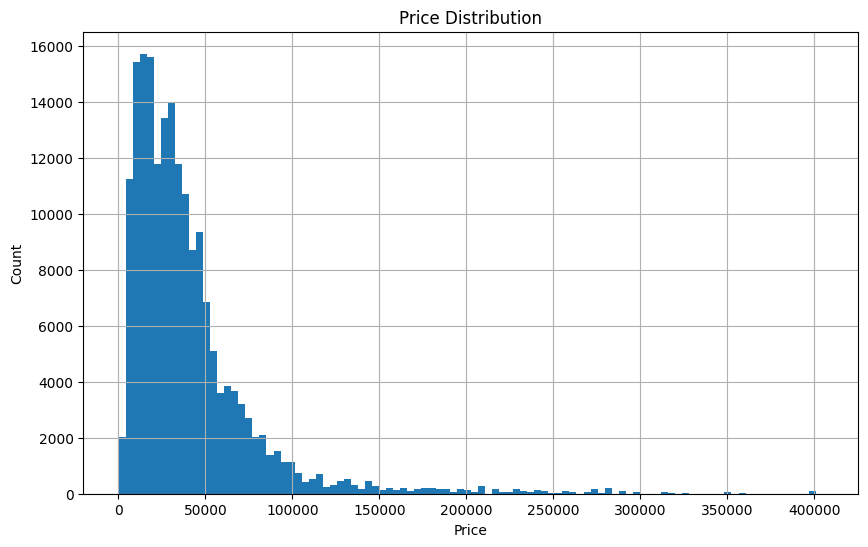

In [ ]:
import matplotlib.pyplot as plt

# binsを50〜100程度にして細かく見る
marged_df["price"].hist(bins=100, range=(100, 405000), figsize=(10, 6))
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [ ]:
marged_df["model_since"] = 2026 - marged_df["model_year"]

# 💡 人間の心理的境界（マイル想定）でカテゴリに分ける
def make_milage_category(m):
    if pd.isna(m):
        return "Unknown"
    elif m < 10000:
        return "Like New"  # 1万マイル未満（ほぼ新車）
    elif m < 30000:
        return "Very Low"  # 3万マイル未満
    elif m < 50000:
        return "Low"  # 5万マイル未満（最初の大きな心理的壁）
    elif m < 80000:
        return "Medium"  # 8万マイル未満
    elif m < 100000:
        return "High"  # 10万マイル未満（2回目の大きな心理的壁）
    else:
        return "Very High"  # 10万マイル以上（過走行車）


# 新しいカテゴリ特徴量を作成
marged_df["milage_psychological_bin"] = marged_df["milage"].apply(
    make_milage_category
)

In [ ]:
import pandas as pd

# ─── 1. price が入っている（欠損していない）行を Train にする ───
train_df = marged_df[marged_df["price"].notnull()].copy()

# ─── 2. price が欠損している行を Test にする ───
test_df = marged_df[marged_df["price"].isnull()].copy()

# ─── 3. Testデータから予測対象である 'price' 列を落とす（お作法） ───
test_df = test_df.drop(columns=["price"])

# 📊 分割後のデータ件数を確認
print(f"📁 元の全体のデータ数: {len(marged_df)}")
print(f"🚗 Train（学習用）のデータ数: {len(train_df)}")
print(f"🔮 Test（予測用）のデータ数 : {len(test_df)}")

📁 元の全体のデータ数: 314223
🚗 Train（学習用）のデータ数: 188533
🔮 Test（予測用）のデータ数 : 125690


In [ ]:
import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error  # scikit-learn 1.4以降
from sklearn.model_selection import KFold

# ─── 1. 使用する特徴量（列）の定義 ───
features = [
    "brand",
    "model_since",
    "pure_model",
    "milage",  # 🔥 細かい数値も重要なので戻しました
    "fuel_type",
    "transmission",
    "accident",
    "clean_title",
    "displacement_l",
    "engine_type_clean",
    "milage_psychological_bin",  # あなたが考えた過学習防止カテゴリ
]

# ─── 2. 文字列データを「category型」に一括変換 ───
for col in features:
    if marged_df[col].dtype == "object":
        marged_df[col] = marged_df[col].astype("category")

# ─── 3. priceを基準にTrainとTestに切り分け ───
train_df = marged_df[marged_df["price"].notnull()].copy()
test_df = marged_df[marged_df["price"].isnull()].copy()

X = train_df[features]
y = train_df["price"]
# 💡 【超重要】ターゲットをここで対数変換する！
y_log = np.log1p(y)

X_test = test_df[features]

# ─── 4. 交差検証（5-Fold KFold）の準備 ───
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# スコアや予測結果を格納する箱（対数ではなく、すべて元のドル/円スケールで保存します）
oof_preds_original = np.zeros(len(X))
test_preds_original = np.zeros(len(X_test))
cv_scores_original = []

# ─── 5. 交差検証ループの実行 ───
print("🚀 LightGBM 5-Fold Cross Validation【対数変換版】開始...\n" + "─" * 45)

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y_log)):
    # データの分割（yは対数化した y_log を切り出す）
    X_train, y_train_log = X.iloc[train_idx], y_log.iloc[train_idx]
    X_val, y_val_log = X.iloc[val_idx], y_log.iloc[val_idx]

    # LightGBM専用のデータセット形式に変換
    train_dataset = lgb.Dataset(X_train, label=y_train_log)
    val_dataset = lgb.Dataset(X_val, label=y_val_log, reference=train_dataset)

    # ハイパーパラメータの設定
    params = {
        "objective": "regression",
        "metric": "rmse",  # 対数空間での誤差を最小化
        "learning_rate": 0.05,
        "max_depth": 6,  # 🌲 過学習を防ぐための制限
        "num_leaves": 31,
        "min_data_in_leaf": 50,
        "colsample_bytree": 0.7,
        "random_state": 42 + fold,
        "verbose": -1,
    }

    # モデルの訓練
    model = lgb.train(
        params,
        train_dataset,
        num_boost_round=2000,
        valid_sets=[train_dataset, val_dataset],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(100),
        ],
    )

    # 1. 検証データでの予測（対数スケールで出てくる）
    val_preds_log = model.predict(X_val, num_iteration=model.best_iteration)

    # 2. 🔥 【重要】元のスケール（ドル/円）に逆変換！
    val_preds_original = np.expm1(val_preds_log)
    oof_preds_original[val_idx] = val_preds_original

    # 3. テストデータの予測（対数から元スケールに戻して平均化へ）
    test_preds_log = model.predict(X_test, num_iteration=model.best_iteration)
    test_preds_original += np.expm1(test_preds_log) / 5

    # 4. 元のスケールでの本当のRMSEスコアを計算
    y_val_original = np.expm1(y_val_log)
    fold_score = root_mean_squared_error(y_val_original, val_preds_original)
    cv_scores_original.append(fold_score)

    print(f"🔹 Fold {fold+1} 元スケール換算 RMSE: {fold_score:,.2f}")
    print("─" * 45)

# ─── 6. 全体の検証結果の表示 ───
oof_score = root_mean_squared_error(y, oof_preds_original)
print(f"🏆 5-Fold 平均 元スケール RMSE : {np.mean(cv_scores_original):,.2f}")
print(f"🏆 全体 OOF  元スケール RMSE  : {oof_score:,.2f}")

# test_dfに予測結果を格納
test_df["predicted_price"] = test_preds_original

🚀 LightGBM 5-Fold Cross Validation【対数変換版】開始...
─────────────────────────────────────────────
[100]	training's rmse: 0.483871	valid_1's rmse: 0.496409
[200]	training's rmse: 0.478703	valid_1's rmse: 0.494999
[300]	training's rmse: 0.4747	valid_1's rmse: 0.494405
[400]	training's rmse: 0.471728	valid_1's rmse: 0.494214
[500]	training's rmse: 0.469146	valid_1's rmse: 0.494116
🔹 Fold 1 元スケール換算 RMSE: 68,709.99
─────────────────────────────────────────────
[100]	training's rmse: 0.484425	valid_1's rmse: 0.492207
[200]	training's rmse: 0.478825	valid_1's rmse: 0.49078
[300]	training's rmse: 0.475261	valid_1's rmse: 0.490306
[400]	training's rmse: 0.472251	valid_1's rmse: 0.49023
[500]	training's rmse: 0.469684	valid_1's rmse: 0.49022
🔹 Fold 2 元スケール換算 RMSE: 69,108.31
─────────────────────────────────────────────
[100]	training's rmse: 0.484147	valid_1's rmse: 0.494765
[200]	training's rmse: 0.478874	valid_1's rmse: 0.493692
[300]	training's rmse: 0.475531	valid_1's rmse: 0.493447
[400]	trainin